In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.stats import norm
import math
import sklearn.preprocessing
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import *
import pickle
from scipy import interpolate
import random
import time
from lightgbm import LGBMRegressor
# import optuna
from sklearn.metrics import mean_absolute_error
from sklearn.multioutput import MultiOutputRegressor
from scipy.stats import linregress
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import r2_score as R2
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_absolute_percentage_error as MAPE
from sklearn.metrics import root_mean_squared_error as RMSE


import argparse
import torch
import torch.nn as nn
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F
import pandas as pd


In [ ]:
dict_R2 = {}
list_ex = ['3Dex1', '3Dex2', '3Dex3', '3Dex4', '3Dex5', '3Dex6', '3Dex7', '3Dex8', '3Dex9', '3Dex10']

L_signal_input = 3000
L_ground = 3000
iograph = 1
Nfeature_node = 10
Nfeature_edge = 8
Nstory_max = 11 # include base
Nnode_max = 5

list_input_time = ['disp_ground', 'encode_0', 'encode_1']
list_output_time = ['disp_2', 'disp_3', 'disp_4', 'disp_5', 'disp_6', 'disp_7', 'disp_8', 'disp_9', 'disp_10', 'disp_11']
list_static = ['fc', 'Ec', 'Fy', 'Es', 'damp', 'g']
L_all, L_out = 800, 750
sliding_step = 750
list_time_series = list_input_time + list_output_time
L_in = L_all-L_out
N_input= len(list_input_time)
N_output= len(list_output_time)
N_static = len(list_static)
N_all = N_input+N_output+N_static
N_time_series = len(list_input_time)+len(list_output_time)+1


In [ ]:
with open(f'EQall.p','rb') as f:
  EQall = pickle.load(f)

with open(f'list_EQ_id.p', 'rb') as f:
    list_EQid = pickle.load(f)


### Data_processing

In [ ]:
def getPositionEncoding(seq_len, d, n=10000):
    P = np.zeros((seq_len, d))
    for k in range(seq_len):
        for i in np.arange(int(d/2)):
            denominator = np.power(n, 2*i/d)
            P[k, 2*i] = np.sin(k/denominator)
            P[k, 2*i+1] = np.cos(k/denominator)
    return P


In [ ]:
def get_data(ex_name):

  with open(f'graph_p_data_allEQ_{ex_name}.p', 'rb') as f:
    df_new = pickle.load(f)

  for i in range(len(df_new)):
    L = len(df_new['disp_ground'][i])
    if L >3000:
      df_new['disp_ground'][i] = df_new['disp_ground'][i][:3000]
    else:
      df_new['disp_ground'][i] = list(df_new['disp_ground'][i]) + [0]*(3000-L)

  list_output_time = []
  list_node = []
  list_edge = []

  for k in list(df_new):
    if (str(k)[:4] == 'disp') & (str(k)[-1] != 'd'):
      list_output_time.append(k)


  N_output_actual = len(list_output_time)

  Ndim_encoding = 2
  P_encoding = getPositionEncoding(seq_len=L_signal_input, d=Ndim_encoding, n=10000)
  for d in range(Ndim_encoding):
    df_new[f'encode_{d}'] = [P_encoding[:,d]]*len(df_new)

  for i in range(len(df_new)):
    df_new['node_graph'][i] = df_new['node_graph'][i].reshape(-1, Nfeature_node)
    df_new['edge_graph'][i] = df_new['edge_graph'][i].reshape(-1, Nfeature_edge)

  for i in range(N_output_actual, Nstory_max-1):
    df_new[f'disp_{i+2}'] = df_new[f'disp_{N_output_actual+1}'] # [[1]*3000]*len(df_new)

  list_len = np.array([len(df_new['disp_2'][ip]) for ip in range(len(df_new))])
  list_idx = np.where(list_len!=3000)[0]
  df_new = df_new.drop(index=list_idx)
  df_new = df_new.reset_index()

  return df_new[list_time_series+list_static+['node_graph','edge_graph']], N_output_actual


In [ ]:
gc.collect(2)
gc.collect(2)

0

In [ ]:
def prepare_data_batch(x, N1, N2, j = 2):
  N0 = np.shape(x)[1]
  xxx = np.stack([x[:,i:N0 - N1+i+1:j, :] for i in range(N1)], axis=2)
  y = xxx[:,:,-N2:,-len(list_output_time):]

  return np.array(xxx), np.array(y)

In [ ]:
class h_Dataset(Dataset):
    def __init__(self, data_time, data_static, data_y, data_node=None, data_edge=None):
        self.data_time = data_time
        self.data_static = data_static
        self.data_y = data_y
        self.data_node= data_node
        self.data_edge = data_edge

    def __getitem__(self, index):
        seq_time = self.data_time[index]
        seq_static = self.data_static[index]
        seq_y = self.data_y[index]
        seq_node = self.data_node[index]
        seq_edge = self.data_edge[index]
        return seq_time, seq_static, seq_y, seq_node, seq_edge


    def __len__(self):
        return len(self.data_y)


def data_provider2(data_x, data_y, batch_size=128):
    data_set = h_Dataset(data_x, data_y)
    data_loader = DataLoader( data_set, batch_size=batch_size, shuffle=True, drop_last=True)
    return data_set, data_loader



In [ ]:
class PositionalEmbedding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEmbedding, self).__init__()

        pe = torch.zeros(max_len, d_model).float()
        pe.require_grad = False
        position = torch.arange(0, max_len).float().unsqueeze(1)
        div_term = (torch.arange(0, d_model, 2).float() * -(np.log(10000.0) / d_model)).exp()

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return self.pe[:, :x.size(1)]


class TokenEmbedding(nn.Module):
    def __init__(self, c_in, d_model):
        super(TokenEmbedding, self).__init__()
        self.tokenConv = nn.Conv1d(in_channels=c_in, out_channels=d_model, kernel_size=3, padding=1, padding_mode='circular', bias=False)

    def forward(self, x):
        x = self.tokenConv(x.permute(0, 2, 1)).transpose(1, 2)
        return x

class DataEmbedding(nn.Module):
    def __init__(self, c_in, d_model, dropout=0.1):
        super(DataEmbedding, self).__init__()
        self.value_embedding = TokenEmbedding(c_in=c_in, d_model=d_model)
        self.position_embedding = PositionalEmbedding(d_model=d_model)
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
          x = self.value_embedding(x) + self.position_embedding(x)
          return self.dropout(x)

In [ ]:
class Data_aggregation(nn.Module):
    def __init__(self, dropout=0.1, iograph=0):
        super(Data_aggregation, self).__init__()
        self.projection = nn.Sequential(nn.Linear(N_static, L_all), nn.ReLU(), nn.Linear(L_all, L_all))
        self.node = nn.Sequential(nn.Linear(Nnode_max*Nnode_max*Nfeature_node, L_all), nn.ReLU(), nn.Linear(L_all, L_all))
        self.edge = nn.Sequential(nn.Linear(2*Nnode_max*Nnode_max*Nnode_max*Nnode_max*Nfeature_edge, L_all), nn.ReLU(), nn.Linear(L_all, L_all))
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, x_time, x_static, x_node, x_edge):
        x = self.projection(x_static)
        x = self.dropout(x)
        x = x.permute(0, 2, 1)
        xxxnode = self.node(x_node)
        xxxnode = self.dropout(xxxnode)
        xxxnode = xxxnode.permute(0, 2, 1)
        xxxedge = self.edge(x_edge)
        xxxedge = self.dropout(xxxedge)
        xxxedge = xxxedge.permute(0, 2, 1)
        x = torch.cat([x_time, x, xxxnode, xxxedge], dim=2)

        return x


In [ ]:

# [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
def gen_data_AI_batch_2_model(df_new, list_idx):
  signal = [np.stack(list(df_new[k][list_idx])) for k in list_time_series ]
  signal = np.stack(signal).transpose(1,2,0)
  signal = np.pad(signal,((0,0),(L_all,0),(0,0)),constant_values=0.0)
  signal = signal.reshape(-1, N_input + N_output)
  scaled_signal = real_scaler.transform(signal)
  scaled_signal = scaled_signal.reshape(-1, L_ground+L_all, N_input + N_output)
  X_times_series, Y_label = prepare_data_batch(scaled_signal, L_all, L_out, j = sliding_step)
  X_times_series[:,:,L_in:,N_input:N_input+N_output] = 0.0

  static = np.stack(list(df_new[k][list_idx] for k in list_static)).T
  scaled_static = static_scaler.transform(static)
  X_static = scaled_static.reshape(-1,1,1,N_static)
  X_static = np.tile(X_static, [1, X_times_series.shape[1], 1, 1])
  X_node = np.stack(df_new['node_graph'][list_idx].values)
  X_node = np.tile(X_node, [X_times_series.shape[1], 1, 1])
  X_edge = np.stack(df_new['edge_graph'][list_idx].values)
  X_edge = np.tile(X_edge, [X_times_series.shape[1], 1, 1])
  X_times_series = X_times_series.reshape(-1, L_all, N_input+N_output)
  X_static = X_static.reshape(-1, 1, N_static)
  Y_label =  Y_label.reshape(-1, L_out, N_output)

  # node = np.stack(list(df_new[k][list_idx]))

  return X_times_series, X_static, Y_label, X_node, X_edge



In [ ]:
def data_provider2(data_time, data_static, data_y, data_node=None, data_edge=None, batch_size=128):
    data_set = h_Dataset(data_time, data_static, data_y, data_node, data_edge)
    data_loader = DataLoader(data_set, batch_size=batch_size, shuffle=True, drop_last=True)
    return data_set, data_loader


In [ ]:
def FullAttention(queries, keys, values):
      B, L, H, E = queries.shape
      _, S, _, D = values.shape
      scale = 1. / math.sqrt(E)
      scores = torch.einsum("blhe,bshe->bhls", queries, keys)
      A = torch.softmax(scale * scores, dim=-1)
      V = torch.einsum("bhls,bshd->blhd", A, values)
      return V.contiguous()


class AttentionLayer(nn.Module):
    def __init__(self, attention, d_model, dropout, n_heads=4):
        super(AttentionLayer, self).__init__()
        d_keys = d_model // n_heads
        d_values = d_model // n_heads
        self.attention = attention
        self.query_projection = nn.Linear(d_model, d_keys * n_heads)
        self.key_projection = nn.Linear(d_model, d_keys * n_heads)
        self.value_projection = nn.Linear(d_model, d_values * n_heads)
        self.out_projection = nn.Linear(d_values * n_heads, d_model)
        self.n_heads = n_heads
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, L, _ = x.shape
        _, S, _ = x.shape
        H = self.n_heads
        queries = self.query_projection(x).view(B, L, H, -1)
        keys = self.key_projection(x).view(B, S, H, -1)
        values = self.value_projection(x).view(B, S, H, -1)
        out = self.attention(queries,keys,values)
        out = out.view(B, L, -1)
        out = self.out_projection(out)
        x = self.dropout(F.relu(x + out))
        return x

class CNN(nn.Module):
    def __init__(self, d_model):
        super(CNN, self).__init__()
        self.conv = nn.Conv1d(in_channels=d_model, out_channels=d_model, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        # Encoder
        x = x.permute(0, 2, 1)  # Shape: [N_sample, N_timestep, d_model]
        x = self.conv(x)  # Shape: [N_sample, d_model, N_timestep]
        x = self.relu(x)
        x = x.permute(0, 2, 1)  # Shape: [N_sample, d_model, N_timestep]
        return x

class LSTM(nn.Module):
    def __init__(self, d_model):
        super(LSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=d_model, hidden_size=d_model)

    def forward(self, x):
        # Encoder
        x, _ = self.lstm(x)  # Shape: [N_sample, N_timestep / 2, 64]
        return x


class CNNLSTM(nn.Module):
    def __init__(self, d_model):
        super(CNNLSTM, self).__init__()
        self.conv = nn.Conv1d(in_channels=d_model, out_channels=d_model, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.lstm = nn.LSTM(input_size=d_model, hidden_size=d_model)

    def forward(self, x):
        # Encoder
        x = x.permute(0, 2, 1)  # Shape: [N_sample, N_timestep, d_model]
        x = self.conv(x)  # Shape: [N_sample, d_model, N_timestep]
        x = self.relu(x)
        x = x.permute(0, 2, 1)  # Shape: [N_sample, d_model, N_timestep]
        x, _ = self.lstm(x)  # Shape: [N_sample, N_timestep / 2, 64]
        return x

class Mamba_h_2(nn.Module):
    def __init__(self, configs):
        super(Mamba_h_2, self).__init__()
        self.mamba = Mamba(
            d_model = configs.d_model,
            d_state = 16,
            d_conv = 4,
            expand = 2,
        )


    def forward(self, x):
        x = self.mamba(x)
        return x

class ResBlock(nn.Module):
    def __init__(self, configs, L_all=L_all, N_all=N_input+N_output+1+iograph*(2*Nstory_max-1)):
        super(ResBlock, self).__init__()

        self.temporal = nn.Sequential(
            nn.Linear(L_all, configs.d_model),
            nn.ReLU(),
            nn.Linear(configs.d_model, L_all),
            nn.Dropout(configs.dropout)
        )

        self.channel = nn.Sequential(
            nn.Linear(N_all, configs.d_model),
            nn.ReLU(),
            nn.Linear(configs.d_model, N_all),
            nn.Dropout(configs.dropout)
        )

    def forward(self, x):
        # x: [B, L, D]
        x = x + self.temporal(x.transpose(1, 2)).transpose(1, 2)
        x = x + self.channel(x)
        return x



class TSMixer_dis(nn.Module):
    def __init__(self, configs, mtype='TSMixer'):
        super(TSMixer_dis, self).__init__()
        self.layer = configs.e_layers
        self.projection = nn.Sequential(nn.Linear(L_all, L_out), nn.ReLU())
        self.out_layer = nn.ModuleList([nn.Linear(N_input+N_output+1+iograph*(2*Nstory_max-1), N_output, bias=False) for i in range(7)])

        self.projection = nn.Sequential(nn.Linear(L_all, L_out), nn.ReLU())
        self.out_layer = nn.ModuleList([nn.Linear(N_input+N_output+1+iograph*(2*Nstory_max-1), N_output, bias=False) for i in range(7)])

        if mtype == 'TSMixer':
          self.model = nn.ModuleList([ResBlock(configs, L_all, N_input+N_output+1+iograph*(2*Nstory_max-1)) for _ in range(configs.e_layers)])
        elif mtype == 'TSMixer-embed':
          self.model = nn.ModuleList([DataEmbedding(N_input+N_output+1+iograph*(2*Nstory_max-1), configs.d_model, configs.dropout)]
                                    +[ResBlock(configs, L_all, configs.d_model) for _ in range(configs.e_layers)]
                                    +[nn.Sequential(nn.Linear(configs.d_model, N_input+N_output+1+iograph*(2*Nstory_max-1)), nn.ReLU())])
        elif mtype == 'Transformer':
          self.model = nn.ModuleList([DataEmbedding(N_input+N_output+1+iograph*(2*Nstory_max-1), configs.d_model, configs.dropout)]
                                    +[AttentionLayer(FullAttention, configs.d_model, configs.dropout) for _ in range(configs.e_layers)]
                                    +[nn.Sequential(nn.Linear(configs.d_model, N_input+N_output+1+iograph*(2*Nstory_max-1)), nn.ReLU())])
        elif mtype == 'CNNLSTM':
          self.model = nn.ModuleList([DataEmbedding(N_input+N_output+1+iograph*(2*Nstory_max-1), configs.d_model, configs.dropout)]
                                    +[CNNLSTM(configs.d_model) for _ in range(configs.e_layers)]
                                    +[nn.Sequential(nn.Linear(configs.d_model, N_input+N_output+1+iograph*(2*Nstory_max-1)), nn.ReLU())])
        elif mtype == 'CNN':
          self.model = nn.ModuleList([DataEmbedding(N_input+N_output+1+iograph*(2*Nstory_max-1), configs.d_model, configs.dropout)]
                                    +[CNN(configs.d_model) for _ in range(configs.e_layers)]
                                    +[nn.Sequential(nn.Linear(configs.d_model, N_input+N_output+1+iograph*(2*Nstory_max-1)), nn.ReLU())])
        elif mtype == 'LSTM':
          self.model = nn.ModuleList([DataEmbedding(N_input+N_output+1+iograph*(2*Nstory_max-1), configs.d_model, configs.dropout)]
                                    +[LSTM(configs.d_model) for _ in range(configs.e_layers)]
                                    +[nn.Sequential(nn.Linear(configs.d_model, N_input+N_output+1+iograph*(2*Nstory_max-1)), nn.ReLU())])
        elif mtype == 'Mamba':
          self.model = nn.ModuleList([DataEmbedding(N_input+N_output+1+iograph*(2*Nstory_max-1), configs.d_model, configs.dropout)]
                                    +[Mamba_h_2(configs) for _ in range(configs.e_layers)]
                                    +[nn.Sequential(nn.Linear(configs.d_model, N_input+N_output+1+iograph*(2*Nstory_max-1)), nn.ReLU())])

    def forward(self, x_enc):
        x = x_enc
        for i in range(self.layer):
            x = self.model[i](x)

        x = self.projection(x.permute(0, 2, 1)).permute(0, 2, 1)
        x_out = torch.stack([self.out_layer[i](x) for i in range(7)], dim=-1)

        return x_out

class MAE_2():
    def loss(y_pred, target):
        L = torch.zeros(1).to(device)
        for i, q in enumerate([0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]):
          errors = y_pred[:,:,:,i] - target
          L += torch.mean(torch.max((q - 1) * errors, q * errors))

        return L

class model_parameters:
  def __init__(self):
    self.d_model = 128
    self.e_layers = 2
    self.dropout = 0.1


In [ ]:
def inference_5tor(model, aggregation, df_new, list_idx, batch_size = 512):
  x_time, x_static, _, x_node, x_edge = gen_data_AI_batch_2_model(df_new, list_idx)
  x_time = x_time.reshape(len(list_idx),-1,L_all, N_input+N_output)
  x_static = x_static.reshape(len(list_idx),-1, 1, N_static)
  x_node = x_node.reshape(len(list_idx),-1, Nstory_max, Nnode_max*Nnode_max*Nfeature_node)
  x_edge = x_edge.reshape(len(list_idx),-1, Nstory_max-1, (2*Nnode_max*Nnode_max*Nnode_max*Nnode_max*Nfeature_edge))

  # initial a long output time-series with zero
  y_predict_all = np.zeros((len(x_time), L_ground+L_all, N_output))
  y_predict_low = np.zeros((len(x_time), L_ground+L_all, N_output))
  y_predict_high = np.zeros((len(x_time), L_ground+L_all, N_output))

  for j in range(int(L_ground/L_out)+1):
    x_time[:,j,:L_all, N_input:N_input+N_output] = y_predict_all[:,L_out*j:L_all+L_out*j,:]
    xt = torch.from_numpy(x_time[:,j,:,:]).float().to('cuda')
    xs = torch.from_numpy(x_static[:,j,:,:]).float().to('cuda')
    xn = torch.from_numpy(x_node[:,j,:,:]).float().to('cuda')
    xe = torch.from_numpy(x_edge[:,j,:,:]).float().to('cuda')

    batch_x = aggregation(xt, xs, xn, xe)
    y_pred_all = model(batch_x).to('cuda').cpu().detach().numpy()
    y_predict_all[:,L_in+L_out*j:L_all+L_out*j,:] = y_pred_all[:,:,:,3]
    y_predict_low[:,L_in+L_out*j:L_all+L_out*j,:] = y_pred_all[:,:,:,0]
    y_predict_high[:,L_in+L_out*j:L_all+L_out*j,:] = y_pred_all[:,:,:,6]

  y_predict_all = target_scaler.inverse_transform(y_predict_all.reshape(-1, N_output))
  y_predict_all = y_predict_all.reshape(len(x_time), -1, N_output)

  y_predict_low = target_scaler.inverse_transform(y_predict_low.reshape(-1, N_output))
  y_predict_low = y_predict_low.reshape(len(x_time), -1, N_output)

  y_predict_high = target_scaler.inverse_transform(y_predict_high.reshape(-1, N_output))
  y_predict_high = y_predict_high.reshape(len(x_time), -1, N_output)

  return y_predict_all, y_predict_low, y_predict_high

In [ ]:
def compute_metric(df_new, N_output_actual, idx_valid):
  list_MAE, list_R2, list_MAPE, list_RMSE = [], [], [], []
  list_ip = idx_valid
  y_predict_all, y_predict_low, y_predict_high = inference_5tor(model_tor, aggregation, df_new, list_ip)
  for i,ip in enumerate(list_ip):
    i_s = N_output_actual-1
    if ex == '3Dex10':
      i_s -= 1

    y_pred = y_predict_all[i, L_all:L_all+L_ground,i_s]
    y_actual = df_new[list_output_time[i_s]][ip]
    calMAE = MAE(y_pred, y_actual)
    calMAPE = MAPE(y_pred, y_actual)
    calRMSE = RMSE(y_pred, y_actual)
    calR2 = R2(y_pred, y_actual)
    list_MAE.append(calMAE)
    list_MAPE.append(calMAPE)
    list_RMSE.append(calRMSE)
    list_R2.append(calR2)

  return np.mean(list_MAE), np.mean(list_R2), np.mean(list_MAPE), np.mean(list_RMSE)

In [ ]:
def plot_results(df_new, N_output_actual, idx_valid):
  plt.figure(figsize=(10,14))
  list_ip = [idx_valid[i] for i in np.random.randint(0,len(idx_valid), 4)]
  y_predict_all, y_predict_low, y_predict_high = inference_5tor(model_tor, aggregation, df_new, list_ip)

  list_color = ['r', 'orange', 'm', 'g']
  for i,ip in enumerate(list_ip):
    plt.subplot(421+i*2)
    i_s = np.random.randint(N_output_actual)
    # i_s = 5
    length = len(df_new[list_output_time[i_s]][ip])
    t= np.arange(0,len(df_new[list_output_time[i_s]][ip][:]))*0.01
    plt.plot(t, y_predict_low[i, L_all:L_all+L_ground,i_s][:], linewidth=2)
    plt.plot(t, y_predict_all[i, L_all:L_all+L_ground,i_s][:],list_color[i], linewidth=2)
    plt.plot(t, y_predict_high[i, L_all:L_all+L_ground,i_s][:], linewidth=2)
    plt.plot(t, df_new[list_output_time[i_s]][ip][:],'--k', alpha = 0.6, linewidth=2)
    plt.legend(['upper', 'median', 'lower', 'FEM'], loc=0)
    plt.title(f'{ip} sensor {list_output_time[i_s]}', fontsize=12)
    plt.xlabel('Time (s)')
    plt.ylabel('Displacement (m)')
    # plt.ylim(-0.04, 0.04)
    # plt.xlim(0,28)
    plt.grid(True)


    plt.subplot(422+i*2)
    length = len(df_new[list_output_time[i_s]][ip])
    t= np.arange(0,len(df_new[list_output_time[i_s]][ip][:]))*0.01
    # t1, t2 = 800, 1200
    t1 = np.random.randint(0,2200)
    t2 = t1+500
    yy = y_predict_all[i, L_all:L_all+length,i_s][:]
    plt.plot(t[t1:t2], yy[t1:t2],list_color[i], linewidth=2)
    yy = y_predict_low[i, L_all:L_all+length,i_s][:]
    plt.plot(t[t1:t2], yy[t1:t2], linewidth=2)
    yy = y_predict_high[i, L_all:L_all+length,i_s][:]
    plt.plot(t[t1:t2], yy[t1:t2], linewidth=2)
    yy = df_new[list_output_time[i_s]][ip][:]
    plt.plot(t[t1:t2], yy[t1:t2],'--k', alpha = 0.6, linewidth=2)
    plt.title(f'zoomed-in region {t1/100}-{t2/100}s', fontsize=12)
    plt.xlabel('Time (s)')
    plt.ylabel('Displacement (m)')
    plt.xlim(t1*0.01, t2*0.01)
    plt.grid(True)
    # plt.ylim(-0.042, 0.042)

  plt.tight_layout();
  # plt.savefig(f'{ex_name}_1.png',dpi=400)
  return None

In [ ]:
dict_df_new = {}
dict_Noutput_actual = {}
for ex in list_ex:
  dict_df_new[ex], dict_Noutput_actual[ex] = get_data(ex)


In [ ]:
ex = list_ex[0]
static_scaler = sklearn.preprocessing.StandardScaler().fit(dict_df_new[ex][list_static].values)
target = np.array([dict_df_new[ex][i][0] for i in list_output_time]).T
target_scaler = sklearn.preprocessing.StandardScaler().fit(target)
real = np.array([dict_df_new[ex][i][0] for i in list_time_series]).T
real_scaler = sklearn.preprocessing.StandardScaler().fit(real)

xnode = np.stack(dict_df_new[ex]['node_graph'].values).reshape(-1, Nfeature_node)
xedge = np.stack(dict_df_new[ex]['edge_graph'].values).reshape(-1, Nfeature_edge)
node_mean = np.mean(xnode,axis=0)
node_std =  np.std(xnode,axis=0)
edge_mean = np.mean(xedge,axis=0)
edge_std =  np.std(xedge,axis=0)


In [ ]:
del xnode, xedge

In [ ]:
for ex in list_ex:
  for i in range(len(dict_df_new[ex])):
    xnode = (dict_df_new[ex]['node_graph'][i]  - node_mean)/node_std
    dict_df_new[ex]['node_graph'][i] = xnode.reshape(Nstory_max, -1)
    xedge = (dict_df_new[ex]['edge_graph'][i]  - edge_mean)/np.maximum(edge_std,1.0E-6)
    dict_df_new[ex]['edge_graph'][i] = xedge.reshape(Nstory_max-1, -1)

In [ ]:
len(dict_df_new[ex])

255

In [ ]:
dict_idx_train={}
dict_idx_val={}
for ex in list_ex:
  dict_idx_train[ex] = np.random.choice(len(dict_df_new[ex]), size=200, replace=False)
  dict_idx_val[ex] = [i for i in range(len(dict_df_new[ex])) if i not in dict_idx_train[ex]]


In [ ]:
del xnode, xedge

In [ ]:
gc.collect(2)
gc.collect(2)

0

In [ ]:
list_train_time, list_train_static, list_train_label, list_train_node, list_train_edge = [], [], [], [], []
list_val_time, list_val_static, list_val_label, list_val_node, list_val_edge = [], [], [], [], []
for ex in list_ex:
  time, static, label, node, edge = gen_data_AI_batch_2_model(dict_df_new[ex], dict_idx_train[ex])
  list_train_time.append(time)
  list_train_static.append(static)
  list_train_label.append(label)
  list_train_node.append(node)
  list_train_edge.append(edge)


train_time = np.concatenate(list_train_time, axis=0)
train_static = np.concatenate(list_train_static, axis=0)
train_label = np.concatenate(list_train_label, axis=0)
train_node = np.concatenate(list_train_node, axis=0)
train_edge = np.concatenate(list_train_edge, axis=0)


In [ ]:
del list_train_time, list_train_static, list_train_label, list_train_node, list_train_edge

In [ ]:
for ex in list_ex:
  time, static, label, node, edge = gen_data_AI_batch_2_model(dict_df_new[ex], dict_idx_val[ex])
  list_val_time.append(time)
  list_val_static.append(static)
  list_val_label.append(label)
  list_val_node.append(node)
  list_val_edge.append(edge)


val_time = np.concatenate(list_val_time, axis=0)
val_static = np.concatenate(list_val_static, axis=0)
val_label = np.concatenate(list_val_label, axis=0)
val_node = np.concatenate(list_val_node, axis=0)
val_edge = np.concatenate(list_val_edge, axis=0)

del list_val_time, list_val_static, list_val_label, list_val_node, list_val_edge

In [ ]:
_, train_loader = data_provider2(train_time, train_static, train_label, train_node, train_edge, batch_size=64)
_, valid_loader = data_provider2(val_time, val_static, val_label, val_node, val_edge, batch_size=64)


In [ ]:
args = model_parameters()
model_tor = TSMixer_dis(args)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
aggregation = Data_aggregation()
aggregation = aggregation.float().to(device)
model_tor = model_tor.float().to(device)
model_optim = torch.optim.Adam(list(model_tor.parameters())+list(aggregation.parameters()), lr=0.001)
criterion = MAE_2


In [ ]:
gc.collect(2)
gc.collect(2)

0

### Train

In [ ]:
%%time
args = model_parameters()
model_tor = TSMixer_dis(args)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
aggregation = Data_aggregation()
aggregation = aggregation.float().to(device)
model_tor = model_tor.float().to(device)
model_optim = torch.optim.Adam(list(model_tor.parameters())+list(aggregation.parameters()), lr=0.001)
criterion = MAE_2

N_epoch = 50
model_optim = torch.optim.Adam(list(model_tor.parameters())+list(aggregation.parameters()), lr=0.001)

for epoch in range(N_epoch):
    train_loss = []
    for batch_time, batch_static, batch_y, batch_node, batch_edge in train_loader:
        model_optim.zero_grad()
        batch_node, batch_edge = torch.zeros(batch_node.shape), torch.zeros(batch_edge.shape)
        batch_time, batch_static, batch_y, batch_node, batch_edge = batch_time.float().to(device), batch_static.float().to(device), batch_y.float().to(device), batch_node.float().to(device), batch_edge.float().to(device)
        batch_x = aggregation(batch_time, batch_static, batch_node, batch_edge)
        outputs = model_tor(batch_x)
        loss = criterion.loss(outputs, batch_y)
        loss.backward()
        train_loss.append(loss.item())
        model_optim.step()

    if epoch % 2 ==0:
      valid_loss = []
      for batch_time, batch_static, batch_y, batch_node, batch_ege in valid_loader:
        batch_time, batch_static, batch_y, batch_node, batch_edge = batch_time.float().to(device), batch_static.float().to(device), batch_y.float().to(device), batch_node.float().to(device), batch_edge.float().to(device)
        batch_x = aggregation(batch_time, batch_static, batch_node, batch_edge)
        outputs = model_tor(batch_x)
        loss = criterion.loss(outputs, batch_y)

        valid_loss.append(loss.item())

      print(f"epoch: {epoch} | loss: {np.mean(train_loss)}, valid loss: {np.mean(valid_loss)}")


dict_MAE, dict_R2, dict_MAPE, dict_RMSE = {}, {}, {}, {}
for ex in list_ex:
  dict_MAE[ex], dict_R2[ex], dict_MAPE[ex], dict_RMSE[ex] = compute_metric(dict_df_new[ex], dict_Noutput_actual[ex], dict_idx_val[ex])

dict_R2, dict_MAE, dict_MAPE, dict_RMSE

In [ ]:
dict_MAE, dict_R2, dict_MAPE, dict_RMSE = {}, {}, {}, {}
for ex in list_ex:
  dict_MAE[ex], dict_R2[ex], dict_MAPE[ex], dict_RMSE[ex] = compute_metric(dict_df_new[ex], dict_Noutput_actual[ex], dict_idx_val[ex])

dict_R2, dict_MAE, dict_MAPE, dict_RMSE

In [ ]:
# with open('3D_all_model_tor_3Dex8.p','wb') as f:
#   pickle.dump(model_tor,f)
#   pickle.dump(aggregation,f)
#   pickle.dump(dict_idx_train,f)
#   pickle.dump(dict_idx_val,f)

### Plot results to paper

In [ ]:
from matplotlib import rcParams, rc
rcParams['font.family'] = 'serif'
rcParams['font.sans-serif'] = ['Time New Roman']
fsize = 10
rcParams.update({'font.size': fsize})

In [ ]:
with open('3D_all_model_tor_3Dex8.p','rb') as f:
  model_tor = pickle.load(f)
  aggregation = pickle.load(f)
  dict_idx_train = pickle.load(f)
  dict_idx_val = pickle.load(f)

In [ ]:
def plot_results(axs, df_new, N_output_actual, idx_valid, fsize=10, ia=0):
  list_ip = [idx_valid[i] for i in np.random.randint(0,len(idx_valid), 1)]
  y_predict_all, y_predict_low, y_predict_high = inference_5tor(model_tor, aggregation, df_new, list_ip)

  list_color = ['r', 'orange', 'm', 'g']
  for i,ip in enumerate(list_ip):
    i_s = np.random.randint(N_output_actual)
    # i_s = 5
    length = len(df_new[list_output_time[i_s]][ip])
    t= np.arange(0,len(df_new[list_output_time[i_s]][ip][:]))*0.01
    axs[ia, 0].plot(t, y_predict_low[i, L_all:L_all+L_ground,i_s][:]*1E3, linewidth=2)
    axs[ia, 0].plot(t, y_predict_all[i, L_all:L_all+L_ground,i_s][:]*1E3,list_color[i], linewidth=2)
    axs[ia, 0].plot(t, y_predict_high[i, L_all:L_all+L_ground,i_s][:]*1E3, linewidth=2)
    axs[ia, 0].plot(t, df_new[list_output_time[i_s]][ip][:]*1E3,'--k', alpha = 0.6, linewidth=2)
    # axs[ia, 0].legend(['upper', 'median', 'lower', 'FEM'], loc=0)
    axs[ia, 0].set_title(f'{ex} id_{ip} {list_output_time[i_s]}', fontsize=fsize)
    if ia==9:
      axs[ia, 0].set_xlabel('Time (s)')
    axs[ia, 0].set_ylabel('Displ. (mm)')
    # plt.ylim(-0.04, 0.04)
    # plt.xlim(0,28)
    axs[ia, 0].grid(True)


    length = len(df_new[list_output_time[i_s]][ip])
    t= np.arange(0,len(df_new[list_output_time[i_s]][ip][:]))*0.01
    # t1, t2 = 800, 1200
    t1 = np.random.randint(0,2200)
    t2 = t1+500
    yy = y_predict_all[i, L_all:L_all+length,i_s][:]
    axs[ia, 1].plot(t[t1:t2], yy[t1:t2]*1E3,list_color[i], linewidth=2)
    yy = y_predict_low[i, L_all:L_all+length,i_s][:]
    axs[ia, 1].plot(t[t1:t2], yy[t1:t2]*1E3, linewidth=2)
    yy = y_predict_high[i, L_all:L_all+length,i_s][:]
    axs[ia, 1].plot(t[t1:t2], yy[t1:t2]*1E3, linewidth=2)
    yy = df_new[list_output_time[i_s]][ip][:]
    axs[ia, 1].plot(t[t1:t2], yy[t1:t2]*1E3,'--k', alpha = 0.6, linewidth=2)
    axs[ia, 1].set_title(f'{ex} zoomed-in {t1/100}-{t2/100}s', fontsize=fsize)
    if ia==9:
      axs[ia, 1].set_xlabel('Time (s)')
    # axs[ia, 1].set_ylabel('Displacement (mm)')
    axs[ia, 1].set_xlim(t1*0.01, t2*0.01)
    axs[ia, 1].grid(True)
    # plt.ylim(-0.042, 0.042)


  # plt.savefig(f'{ex_name}_1.png',dpi=400)

In [ ]:
from matplotlib import rcParams, rc
rcParams['font.family'] = 'serif'
rcParams['font.sans-serif'] = ['Time New Roman']
fsize = 10
rcParams.update({'font.size': fsize})

In [ ]:
np.where(np.array(list_EQid)=='3')

(array([165, 166, 167, 168, 169]),)

In [ ]:
%%time
ex = '3Dex10'
list_ip = [166]
for i in range(100):
  y_predict_all, y_predict_low, y_predict_high = inference_5tor(model_tor, aggregation, dict_df_new[ex], list_ip)


CPU times: user 11.3 s, sys: 0 ns, total: 11.3 s
Wall time: 2.59 s


In [ ]:
def get_model_memory(model):
    total_params = sum(p.numel() for p in model.parameters())
    param_size = next(model.parameters()).element_size()  # Size of one parameter in bytes
    memory = total_params * param_size / (1024 ** 2)  # Convert to MB
    return memory



In [ ]:
print(f"Model parameter memory: {get_model_memory(model_tor):.2f} MB")

Model parameter memory: 3.94 MB


In [ ]:
print(f"Model parameter memory: {get_model_memory(aggregation):.2f} MB")

Model parameter memory: 38.64 MB


In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary

In [ ]:
summary(aggregation)
summary(model_tor)

In [ ]:
gc.collect(2)
gc.collect(2)

0

CPU times: user 1.95 s, sys: 18.8 ms, total: 1.97 s
Wall time: 1.32 s


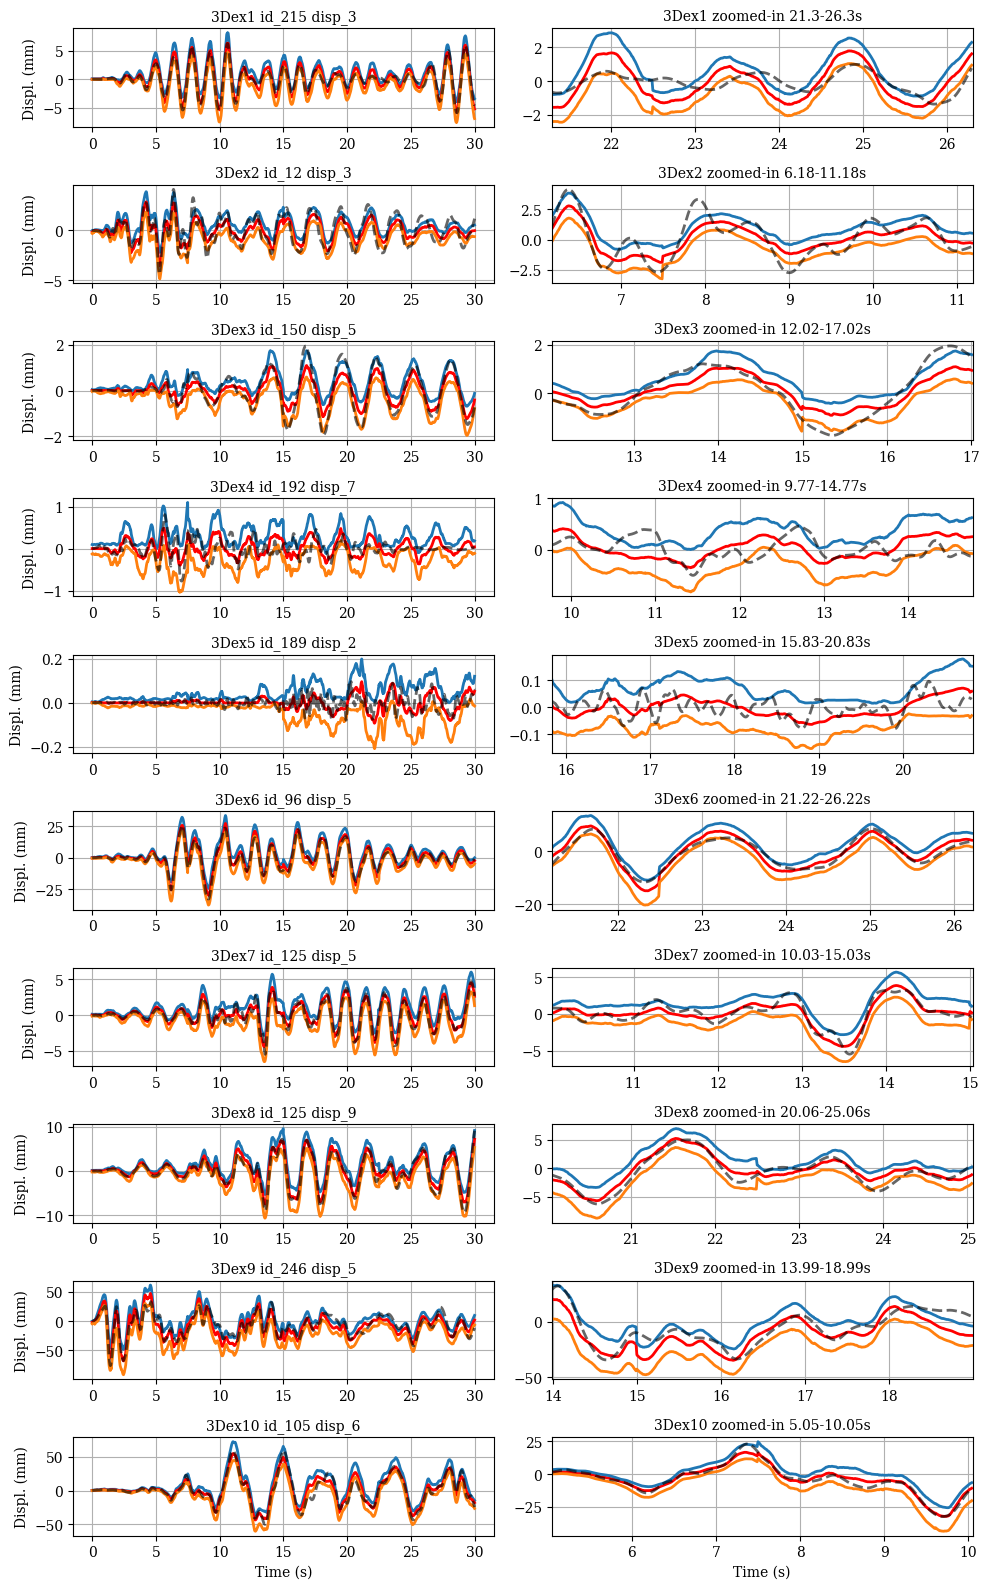

In [ ]:
%%time
list_ex = ['3Dex1', '3Dex2', '3Dex3', '3Dex4', '3Dex5', '3Dex6', '3Dex7', '3Dex8', '3Dex9', '3Dex10' ]
fig, axs = plt.subplots(10,2, figsize=(10, 16))
for ia, ex in enumerate(list_ex):
  plot_results(axs, dict_df_new[ex], dict_Noutput_actual[ex], dict_idx_val[ex], fsize, ia)

plt.tight_layout();

In [ ]:
def plot_results2(axs, df_new, N_output_actual, idx_valid, list_ip=None, fsize=10, ia=0):
  if list_ip is None:
    list_ip = [idx_valid[i] for i in np.random.randint(0,len(idx_valid), 1)]
  # print(list_ip)

  y_predict_all, y_predict_low, y_predict_high = inference_5tor(model_tor, aggregation, df_new, list_ip)

  list_color = ['r', 'orange', 'm', 'g']
  for i,ip in enumerate(list_ip):
    i_s = np.random.randint(N_output_actual)
    # i_s = 5
    length = len(df_new[list_output_time[i_s]][ip])
    t= np.arange(0,len(df_new[list_output_time[i_s]][ip][:]))*0.01
    axs[ia, 0].plot(t, y_predict_low[i, L_all:L_all+L_ground,i_s][:]*1E3, linewidth=2)
    axs[ia, 0].plot(t, y_predict_all[i, L_all:L_all+L_ground,i_s][:]*1E3,list_color[i], linewidth=2)
    axs[ia, 0].plot(t, y_predict_high[i, L_all:L_all+L_ground,i_s][:]*1E3, linewidth=2)
    axs[ia, 0].plot(t, df_new[list_output_time[i_s]][ip][:]*1E3,'--k', alpha = 0.6, linewidth=2)
    # axs[ia, 0].legend(['upper', 'median', 'lower', 'FEM'], loc=0)
    axs[ia, 0].set_title(f'{ex} id_{ip} {list_output_time[i_s]}', fontsize=fsize)
    if ia==4:
      axs[ia, 0].set_xlabel('Time (s)')
    axs[ia, 0].set_ylabel('Displ. (mm)')
    # plt.ylim(-0.04, 0.04)
    # plt.xlim(0,28)
    axs[ia, 0].grid(True)


    length = len(df_new[list_output_time[i_s]][ip])
    t= np.arange(0,len(df_new[list_output_time[i_s]][ip][:]))*0.01
    yyy = df_new[list_output_time[i_s]][ip][:]*1E3
    ypp = y_predict_all[i, L_all:L_all+length,i_s][:]*1E3
    ttt = np.argmax(yyy)
    t1 = ttt-150
    # t1 = np.random.randint(0,2200)
    t2 = t1+300
    yy = y_predict_all[i, L_all:L_all+length,i_s][:]
    axs[ia, 1].plot(t[t1:t2], yy[t1:t2]*1E3,list_color[i], linewidth=2)
    yy = y_predict_low[i, L_all:L_all+length,i_s][:]
    axs[ia, 1].plot(t[t1:t2], yy[t1:t2]*1E3, linewidth=2)
    yy = y_predict_high[i, L_all:L_all+length,i_s][:]
    axs[ia, 1].plot(t[t1:t2], yy[t1:t2]*1E3, linewidth=2)
    yy = df_new[list_output_time[i_s]][ip][:]
    axs[ia, 1].plot(t[t1:t2], yy[t1:t2]*1E3,'--k', alpha = 0.6, linewidth=2)
    axs[ia, 1].set_title(f'{ex} zoomed-in {t1/100}-{t2/100}s', fontsize=fsize)

    # Annotate peak with arrow and error metric using ax.annotate
    peak_time = t[ttt]
    peak_pred = yyy[ttt]
    abs_error = int(np.abs(yyy[ttt]  - ypp[ttt])/yyy[ttt]*100)
    axs[ia, 1].annotate(
        f'peak error: {abs_error:.0f}%',
        xy=(peak_time, peak_pred),
        xytext=(peak_time-1.5, peak_pred),
        arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
        bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white'),
        color='red'
    )



    if ia==4:
      axs[ia, 1].set_xlabel('Time (s)')
    # axs[ia, 1].set_ylabel('Displacement (mm)')
    axs[ia, 1].set_xlim(t1*0.01, t2*0.01)
    axs[ia, 1].grid(True)
    # plt.ylim(-0.042, 0.042)


  # plt.savefig(f'{ex_name}_1.png',dpi=400)

CPU times: user 2.61 s, sys: 19.5 ms, total: 2.63 s
Wall time: 2.21 s


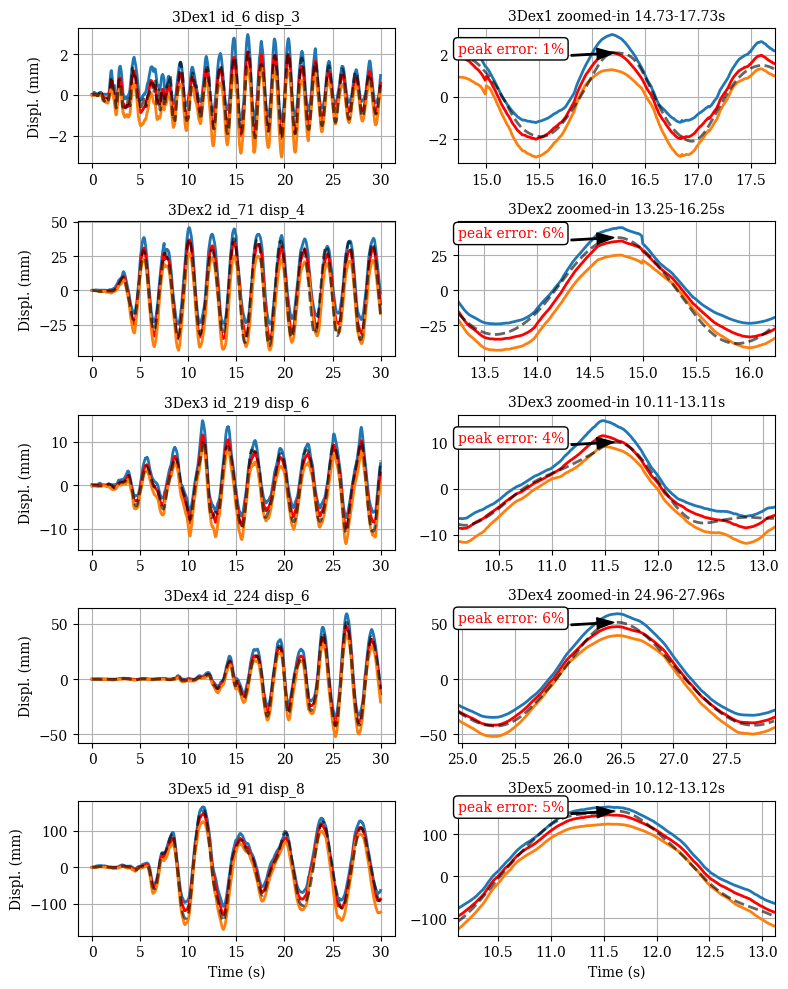

In [ ]:
%%time
list_ex = ['3Dex1','3Dex2', '3Dex3', '3Dex4', '3Dex5']
list_ip = [6, 71, 219, 224, 91]
fig, axs = plt.subplots(len(list_ex),2, figsize=(8, 10))
for ia, ex in enumerate(list_ex):
  plot_results2(axs, dict_df_new[ex], dict_Noutput_actual[ex], dict_idx_val[ex], list_ip[ia:ia+1], fsize, ia)
  # plot_results2(axs, dict_df_new[ex], dict_Noutput_actual[ex], dict_idx_val[ex], None, fsize, ia)
dict_idx_val[ex]
plt.tight_layout();
plt.savefig('3Dex_graph_re_1.png', dpi=400)

CPU times: user 2.64 s, sys: 14 ms, total: 2.65 s
Wall time: 2.23 s


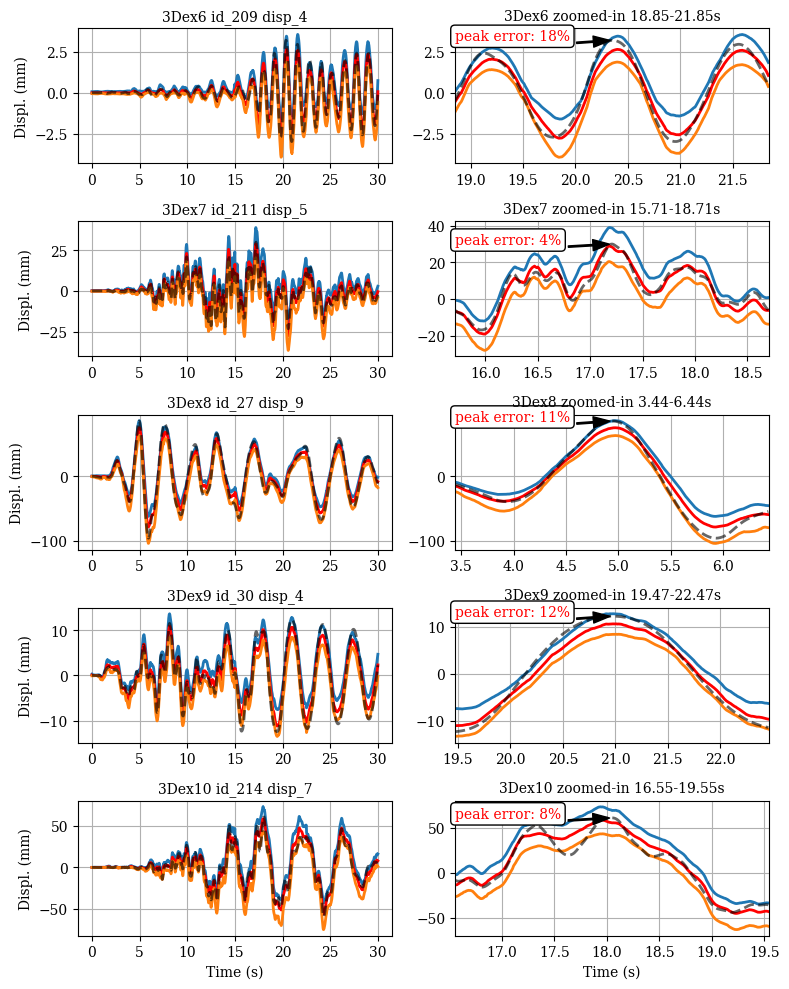

In [ ]:
%%time
list_ex = ['3Dex6','3Dex7', '3Dex8', '3Dex9', '3Dex10']
list_ip = [74, 4 , 31, 118, 62]
fig, axs = plt.subplots(len(list_ex),2, figsize=(8, 10))
for ia, ex in enumerate(list_ex):
  # plot_results2(axs, dict_df_new[ex], dict_Noutput_actual[ex], dict_idx_val[ex], list_ip[ia:ia+1], fsize, ia)
  plot_results2(axs, dict_df_new[ex], dict_Noutput_actual[ex], dict_idx_val[ex], None, fsize, ia)
dict_idx_val[ex]
plt.tight_layout();
plt.savefig('3Dex_graph_re_22.png', dpi=400)

In [ ]:
from matplotlib import rcParams, rc
rcParams['font.family'] = 'serif'
rcParams['font.sans-serif'] = ['Time New Roman']
fsize = 10
rcParams.update({'font.size': fsize})

In [ ]:
def maxpredict(axs, df_new, idx_valid, fsize=10, ia=0):
  list_ip = idx_valid
  y_predict_all, y_predict_low, y_predict_high = inference_5tor(model_tor, aggregation, df_new, list_ip)
  y_predict_all = np.transpose(y_predict_all, (0,2,1))[:,:,L_all:]
  y_predict_low = np.transpose(y_predict_low, (0,2,1))[:,:,L_all:]
  y_predict_high = np.transpose(y_predict_high, (0,2,1))[:,:,L_all:]
  yy = np.array(df_new[list_output_time].iloc[idx_valid].values)
  y_actual = np.array([np.stack(y) for y in yy])
  y_predict_all.shape, y_actual.shape
  ymax_actual = np.max(y_actual, axis=2)*1E3
  ymax_predict = np.max(y_predict_all, axis=2)*1E3
  ymax_high = np.max(y_predict_high, axis=2)*1E3
  ymax_low = np.max(y_predict_low, axis=2)*1E3
  ymax_actual.shape
  istory = ymax_actual.shape[1]-1
  if ex == '3Dex10':
    istory = ymax_actual.shape[1]-2

  xx = np.array([0, np.max(ymax_actual[:,istory])])
  slope_high, intercept_high, _, _, _ = linregress(ymax_actual[:,istory], ymax_high[:,istory])
  y_fit_high = slope_high * xx + intercept_high
  slope_low, intercept_low, _, _, _ = linregress(ymax_actual[:,istory], ymax_low[:,istory])
  y_fit_low = slope_low * xx + intercept_low
  slope, intercept, _, _, _ = linregress(ymax_actual[:,istory], ymax_predict[:,istory])
  y_fit = slope * xx + intercept
  ir, ic = ia//2, ia%2
  axs[ir, ic].plot(xx, y_fit_low, color='blue',label='upper-fit')
  axs[ir, ic].plot(xx, y_fit, '-r',label='median-fit')
  axs[ir, ic].plot([np.min(ymax_actual[:,istory]), np.max(ymax_actual[:,istory])], [np.min(ymax_actual[:,istory]), np.max(ymax_actual[:,istory])], '--k',label='FEM')
  ylim = np.max(ymax_low[:,istory])
  axs[ir, ic].scatter(ymax_actual[:,istory], ymax_high[:,istory], color='green', marker='*')
  axs[ir, ic].scatter(ymax_actual[:,istory], ymax_predict[:,istory], color = 'red', marker='o')
  axs[ir, ic].plot(xx, y_fit_high, color='green',label='lower-fit')
  axs[ir, ic].scatter(ymax_actual[:,istory], ymax_low[:,istory], color='blue', marker='^')
  axs[ir, ic].fill_between(xx, y_fit_low, y_fit_high, color="gray", alpha=0.2)
  axs[ir, ic].set_xlim(0)
  axs[ir, ic].set_ylim(0)
  axs[ir, ic].legend()
  axs[ir, ic].set_xlabel('Actual values (mm)')
  axs[ir, ic].set_ylabel('Prediction (mm)');
  axs[ir, ic].set_title(f'{ex}: max displacement', fontsize=fsize+2)

  return None

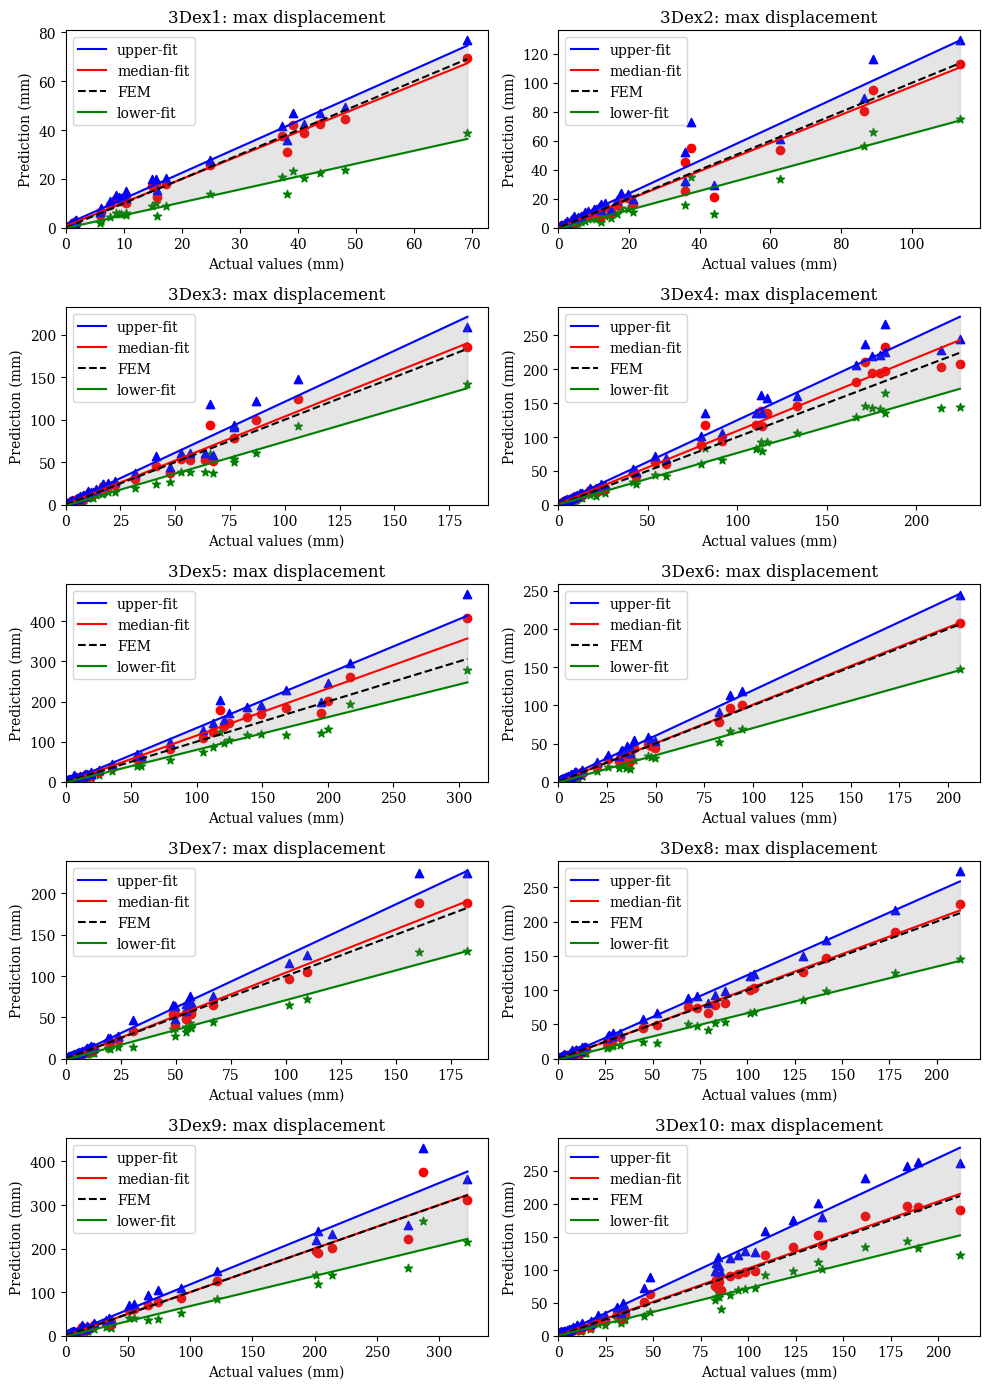

In [ ]:
list_ex = ['3Dex1', '3Dex2', '3Dex3', '3Dex4', '3Dex5', '3Dex6', '3Dex7', '3Dex8', '3Dex9', '3Dex10'] #g00d
fig, axs = plt.subplots(5,2, figsize=(10, 14))
for ia, ex in enumerate(list_ex):
  maxpredict(axs, dict_df_new[ex], dict_idx_val[ex], fsize, ia)

plt.tight_layout();


In [ ]:
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_absolute_percentage_error as MAPE
from sklearn.metrics import root_mean_squared_error as RMSE
from sklearn.metrics import r2_score as R2

In [ ]:
with open('3D_all_model_tor_100.p','rb') as f:
  model_tor = pickle.load(f)
  aggregation = pickle.load(f)
  dict_idx_train = pickle.load(f)
  dict_idx_val = pickle.load(f)

In [ ]:
def compute_metric(df_new, N_output_actual, idx_valid):
  list_MAE, list_R2, list_MAPE, list_RMSE = [], [], [], []
  list_ip = idx_valid
  y_predict_all, y_predict_low, y_predict_high = inference_5tor(model_tor, aggregation, df_new, list_ip)
  for i,ip in enumerate(list_ip):
    i_s = N_output_actual-1
    if ex == '3Dex10':
      i_s -= 1

    y_pred = y_predict_all[i, L_all:L_all+L_ground,i_s]
    y_actual = df_new[list_output_time[i_s]][ip]
    calMAE = MAE(y_pred, y_actual)
    calMAPE = MAPE(y_pred, y_actual)
    calRMSE = RMSE(y_pred, y_actual)
    calR2 = R2(y_pred, y_actual)
    list_MAE.append(calMAE)
    list_MAPE.append(calMAPE)
    list_RMSE.append(calRMSE)
    list_R2.append(calR2)

  return np.mean(list_MAE), np.mean(list_R2), np.mean(list_MAPE), np.mean(list_RMSE)

In [ ]:
dict_MAE, dict_R2, dict_MAPE, dict_RMSE = {}, {}, {}, {}
for ex in list_ex:
  dict_MAE[ex], dict_R2[ex], dict_MAPE[ex], dict_RMSE[ex] = compute_metric(dict_df_new[ex], dict_Noutput_actual[ex], dict_idx_val[ex])

dict_R2, dict_MAE, dict_MAPE, dict_RMSE